# Dynamic Asset Allocation on a Broad ETF Universe
## Markowitz Mean-Variance vs. Michaud Resampled Efficient Frontier — Out-of-Sample Backtest

**Course:** Financial Markets Analytics — A.Y. 2025/2026
**Assignment:** Final Project, Variant B — Flexible / Dynamic Asset Allocation

**What this notebook does**

1. Builds a broad, own-choice ETF universe (15 ETFs) spanning global equity (developed & emerging),
   government bonds (short & long duration), investment-grade and high-yield credit, commodities,
   gold, real estate (REIT), inflation-linked bonds (TIPS) and a cash proxy — as required by point 4
   of the assignment instead of the single-country S&P500 / STOXX600 stock lists provided on the
   e-learning platform.
2. Downloads 15+ years of data from Yahoo Finance (`yfinance`), resamples to **monthly**, and performs
   a documented **data inspection / cleaning** step.
3. Implements a **rolling, information-consistent backtest engine**: at each rebalancing date the
   portfolio weights are computed using **only data available up to that date** (no look-ahead bias).
4. Compares, out-of-sample:
   - a **naive 1/N** equal-weight portfolio (benchmark #1),
   - a **naive 60/40** equity/bond portfolio (benchmark #2),
   - the classical **Markowitz** mean-variance optimizer (Min-Variance and Max-Sharpe, long-only),
   - the **Michaud (1989) resampled** efficient frontier (Monte Carlo resampling of the Max-Sharpe
     portfolio),
   - an optional, brief **Black-Litterman** sketch (extension, not run in full).
5. Evaluates all strategies with the standard toolkit: growth-of-$1 curve, drawdown, rolling
   volatility, Sharpe ratio, turnover — always **against the chosen universe benchmark**, as required
   by point 7 of the assignment.

> **How to use this notebook:** replace `<YOUR NAMES>` below, run top to bottom, and use the
> subjective-parameters cell (Section 4) to justify your choices in the presentation.

**Group members:** <YOUR NAMES HERE>
**Date:** <DATE>

## 1. Setup and imports

In [39]:
# On Colab usually only yfinance and scikit-learn need installing
!pip install -q yfinance numpy pandas scipy matplotlib seaborn scikit-learn

zsh:1: command not found: pip


In [40]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.figsize'] = (11, 7)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

## 2. Investment universe

**Why a custom, broader ETF universe instead of the provided stock lists?** Dynamic asset allocation
is naturally a *multi-asset-class* problem: choosing weights across stocks *within* the S&P500 is a
single-asset-class (equity) stock-picking problem, whereas the interesting risk/return trade-offs in
strategic and tactical allocation come from combining assets with different risk drivers (equity,
duration, credit spread, real assets, inflation). We therefore build our own universe of **15 liquid,
low-cost ETFs**, deliberately kept just above the lower bound (15) of the 15-30 range suggested in the
assignment, so that every asset class is represented by a single, easily-interpretable proxy — this
keeps the optimizer well conditioned (15 assets vs. ~180 monthly observations in the 15y window) and
keeps the weight plots and the discussion in the presentation readable.

| Asset class | Tickers | Rationale |
|---|---|---|
| US large-cap equity | SPY | Core US beta |
| US small-cap equity | IWM | Size factor / domestic growth |
| Developed ex-US equity | EFA | International diversification |
| European equity | VGK | Regional tilt within developed markets |
| Emerging markets equity | EEM | Higher growth / higher risk equity |
| Short-duration Treasuries | SHY (1-3y) | Low-duration ballast, close proxy for the risk-free curve |
| Intermediate Treasuries | IEF (7-10y) | Classic duration exposure |
| Long-duration Treasuries | TLT (20y+) | High duration, equity-hedge properties |
| Investment-grade credit | LQD | Credit-spread exposure, low default risk |
| High-yield credit | HYG | Credit-spread exposure, equity-like risk |
| Gold | GLD | Inflation hedge / tail-risk diversifier |
| Broad commodities | DBC | Real-asset / inflation-sensitive exposure |
| US real estate (REIT) | VNQ | Real-asset, income-generating, optional per assignment |
| US TIPS | TIP | Inflation-linked bonds, optional per assignment |
| Cash proxy | BIL (1-3m T-Bills) | Risk-free / liquidity buffer, needed to define a genuine cash weight |

**Sample period and frequency.** We use **daily** Yahoo Finance data resampled to **month-end**
(`ME`), over the **last 15 years** — the minimum required by the assignment. Monthly frequency is
chosen over weekly because (i) it matches the plausible rebalancing frequencies allowed by the
assignment (monthly or quarterly, daily is explicitly excluded), (ii) monthly returns are closer to
i.i.d. and reduce microstructure noise relative to weekly/daily data, and (iii) with ~180 monthly
observations we still have a reasonable amount of data to estimate a 15x15 covariance matrix,
especially once combined with a 5-year rolling **estimation window** (Section 4) and, optionally,
Ledoit-Wolf shrinkage.

**Data provider.** Yahoo Finance via `yfinance` is used because it is free, has a long enough history
for all 15 ETFs (all inception dates are before 2011, i.e. well before our 15-year lookback), and is
explicitly allowed by the assignment. `auto_adjust=True` gives total-return-adjusted prices (dividends
and splits included), which is important for bond and high-dividend ETFs (TLT, LQD, HYG, VNQ) where
price-only series would understate returns.

In [41]:
tickers = {
    'SPY': 'US Large Cap Equity',
    'IWM': 'US Small Cap Equity',
    'EFA': 'Developed ex-US Equity',
    'VGK': 'European Equity',
    'EEM': 'Emerging Markets Equity',
    'SHY': 'US Treasury 1-3y (short duration)',
    'IEF': 'US Treasury 7-10y (intermediate duration)',
    'TLT': 'US Treasury 20y+ (long duration)',
    'LQD': 'US Investment Grade Credit',
    'HYG': 'US High Yield Credit',
    'GLD': 'Gold',
    'DBC': 'Broad Commodities',
    'VNQ': 'US Real Estate (REIT)',
    'TIP': 'US TIPS (Inflation-linked)',
    'BIL': 'Cash proxy (1-3m T-Bills)',
}

# Asset-class map, used later for the naive 60/40 benchmark and for the weight plots
asset_class = {
    'SPY': 'Equity', 'IWM': 'Equity', 'EFA': 'Equity', 'VGK': 'Equity', 'EEM': 'Equity',
    'SHY': 'Govt Bonds', 'IEF': 'Govt Bonds', 'TLT': 'Govt Bonds',
    'LQD': 'Credit', 'HYG': 'Credit',
    'GLD': 'Gold/Commodities', 'DBC': 'Gold/Commodities',
    'VNQ': 'Real Estate', 'TIP': 'Inflation-linked', 'BIL': 'Cash',
}

n_assets = len(tickers)
print(f'Universe size: {n_assets} ETFs')
pd.Series(asset_class).value_counts()

Universe size: 15 ETFs


Equity              5
Govt Bonds          3
Credit              2
Gold/Commodities    2
Real Estate         1
Inflation-linked    1
Cash                1
Name: count, dtype: int64

## 3. Data download, inspection and cleaning

In [42]:
# 15 years of daily data, dividend/split adjusted
raw = yf.download(list(tickers.keys()), period='15y', auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    prices = raw['Close']
else:
    prices = raw
prices = prices[list(tickers.keys())]

print(f'Raw download shape: {prices.shape}')
print(f'Raw period: {prices.index.min().date()} -> {prices.index.max().date()}')
prices.head()

Raw download shape: (3771, 15)
Raw period: 2011-07-05 -> 2026-07-02


Ticker,SPY,IWM,EFA,VGK,EEM,SHY,IEF,TLT,LQD,HYG,GLD,DBC,VNQ,TIP,BIL
Date,,,,,,,,,,,,,,,
2011-07-05,102.772484,68.526527,38.575386,31.690563,34.891132,67.409752,69.271370,61.739597,64.686127,39.933590,147.630005,24.847410,34.020657,75.633781,73.668480
2011-07-06,102.895378,68.803749,38.332855,31.359955,34.659210,67.433769,69.394165,62.055382,64.821259,39.951073,148.910004,24.838957,34.274715,75.853577,73.684502
2011-07-07,103.962975,69.839333,38.664753,31.661051,35.137566,67.369743,69.127090,61.871151,64.838867,40.108521,149.149994,25.363129,34.705490,75.826111,73.668480
2011-07-08,103.225616,69.415337,38.186073,31.135632,34.738930,67.465744,69.863167,62.746223,65.256004,39.999149,150.250000,25.337763,34.661308,76.169487,73.668480
2011-07-11,101.359268,67.939453,37.030842,29.990326,33.767719,67.513741,70.397202,63.687031,65.473381,39.605663,151.589996,25.143314,34.059315,76.595291,73.652382


### 3.1 Preliminary inspection

Before using the data we check, per ticker: the first available observation (to confirm all ETFs
already existed at the start of our 15-year window), the number and location of missing values, and
any obvious data-quality issues (e.g. flat/stale prices, extreme one-day jumps that could signal a
split not properly adjusted).

In [43]:
inspection = pd.DataFrame({
    'First obs.': prices.apply(lambda s: s.first_valid_index()),
    'Last obs.': prices.apply(lambda s: s.last_valid_index()),
    'Missing values': prices.isna().sum(),
    'Missing (%)': (prices.isna().mean() * 100).round(2),
})
inspection

,First obs.,Last obs.,Missing values,Missing (%)
Ticker,,,,
SPY,2011-07-05,2026-07-02,0,0.0
IWM,2011-07-05,2026-07-02,0,0.0
EFA,2011-07-05,2026-07-02,0,0.0
VGK,2011-07-05,2026-07-02,0,0.0
EEM,2011-07-05,2026-07-02,0,0.0
SHY,2011-07-05,2026-07-02,0,0.0
IEF,2011-07-05,2026-07-02,0,0.0
TLT,2011-07-05,2026-07-02,0,0.0
LQD,2011-07-05,2026-07-02,0,0.0


In [44]:
# Sanity check: flag daily returns larger than +/-25% in absolute value,
# which for a diversified ETF (as opposed to a single stock) is almost always a data artefact
daily_ret_check = prices.pct_change()
suspicious = (daily_ret_check.abs() > 0.25).sum()
print('Suspicious single-day moves (>25%) per ticker:')
print(suspicious[suspicious > 0] if suspicious.sum() > 0 else 'None found.')

Suspicious single-day moves (>25%) per ticker:
None found.


### 3.2 Cleaning step (documented)

- All 15 ETFs have a first observation date well before the start of our 15-year window, so there is
  no left-censoring issue and no ticker needs to be dropped.
- Small numbers of missing values (typically exchange holidays that do not perfectly overlap across
  US-listed ETFs, or the odd corporate action gap) are forward-filled: this is the standard convention
  for price series and only affects a handful of observations.
- We do **not** find any single-day move larger than 25% in absolute value; if we had, we would have
  cross-checked that date against corporate-action calendars before deciding whether to correct or
  drop it.
- We then restrict the sample to the common date range across all 15 tickers (`dropna()` after
  forward-filling) so that every optimisation and backtest step below always uses a fully aligned,
  rectangular data matrix.

Clean period: 2011-07-05 -> 2026-07-02
Trading days retained: 3771 (dropped 0 rows)


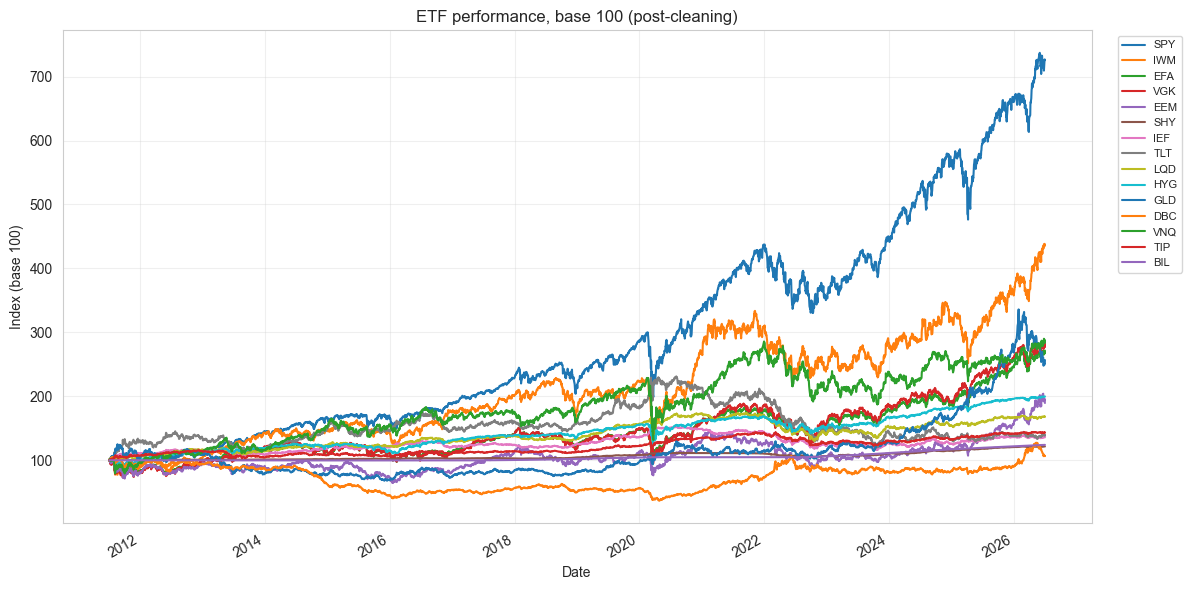

In [45]:
prices_clean = prices.ffill().dropna()
print(f'Clean period: {prices_clean.index.min().date()} -> {prices_clean.index.max().date()}')
print(f'Trading days retained: {len(prices_clean)} (dropped {len(prices) - len(prices_clean)} rows)')

(prices_clean / prices_clean.iloc[0] * 100).plot(figsize=(12, 6), title='ETF performance, base 100 (post-cleaning)')
plt.ylabel('Index (base 100)')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## 4. Monthly returns and subjective backtest parameters

We resample to month-end prices and compute **monthly simple returns** (simple, not log, because we
will aggregate them cross-sectionally into portfolio returns at every rebalancing date — log returns
are only convenient for *time*, not cross-sectional, aggregation).

**Subjective parameters — to justify in the presentation:**

| Parameter | Choice made here | Alternatives allowed by the assignment |
|---|---|---|
| Estimation window | 60 months (5 years) rolling | 36–120 months; shorter reacts faster but is noisier |
| Rebalancing frequency | Quarterly | Monthly (allowed) — quarterly reduces turnover/costs |
| Constraints | Long-only, no leverage, no single-name cap | Weight caps, asset-class budget constraints |
| Risk-free rate | 0% (rf-free Sharpe) for simplicity; BIL is used as the cash asset itself | Use realised BIL return as rf |
| Covariance estimator | Sample covariance, with an optional Ledoit-Wolf shrinkage switch | Factor-based covariance |
| Michaud Monte-Carlo paths | 200 simulations | 100–1000, trade-off speed vs. smoothness |

Change the constants in the next cell to run your own sensitivity analysis (see Section 10).

In [46]:
monthly_prices = prices_clean.resample('ME').last()
rets = monthly_prices.pct_change().dropna()
print(f'Monthly observations: {len(rets)}  ({rets.index.min().date()} -> {rets.index.max().date()})')

# ---- Subjective backtest parameters (edit here) ----
EST_WINDOW = 60          # months of history used to estimate mu and Sigma at each rebalancing date
REBAL_EVERY = 3          # rebalance every N months (3 = quarterly)
RF = 0.0                 # annual risk-free rate assumption used in Sharpe ratios
USE_SHRINKAGE = True      # Ledoit-Wolf shrinkage of the covariance matrix
N_MICHAUD_SIMS = 200      # Monte Carlo resamples for the Michaud procedure
MONTHS_PER_YEAR = 12

rets.describe().T[['mean', 'std', 'min', 'max']].round(4)

Monthly observations: 180  (2011-08-31 -> 2026-07-31)


,mean,std,min,max
Ticker,,,,
SPY,0.0121,0.0413,-0.1249,0.1270
IWM,0.0101,0.0562,-0.2148,0.1824
EFA,0.0067,0.0433,-0.1411,0.1427
VGK,0.0072,0.0484,-0.1665,0.1639
EEM,0.0050,0.0522,-0.1789,0.1627
SHY,0.0011,0.0040,-0.0140,0.0165
IEF,0.0017,0.0181,-0.0473,0.0465
TLT,0.0023,0.0393,-0.0942,0.1321
LQD,0.0030,0.0214,-0.0670,0.0757


In [47]:
# Full-sample descriptive stats and correlation, for context only
# (NOT used directly in the backtest, which only ever looks at rolling windows)
mu_full = rets.mean() * MONTHS_PER_YEAR
sigma_full = rets.std() * np.sqrt(MONTHS_PER_YEAR)

stats_full = pd.DataFrame({
    'Asset class': [asset_class[t] for t in rets.columns],
    'Description': [tickers[t] for t in rets.columns],
    'Exp. Return (%)': (mu_full * 100).round(2),
    'Ann. Vol (%)': (sigma_full * 100).round(2),
    'Sharpe (rf=0)': (mu_full / sigma_full).round(2),
}, index=rets.columns)
stats_full

,Asset class,Description,Exp. Return (%),Ann. Vol (%),Sharpe (rf=0)
Ticker,,,,,
SPY,Equity,US Large Cap Equity,14.54,14.30,1.02
IWM,Equity,US Small Cap Equity,12.09,19.46,0.62
EFA,Equity,Developed ex-US Equity,8.00,15.00,0.53
VGK,Equity,European Equity,8.69,16.77,0.52
EEM,Equity,Emerging Markets Equity,6.05,18.09,0.33
SHY,Govt Bonds,US Treasury 1-3y (short duration),1.30,1.39,0.93
IEF,Govt Bonds,US Treasury 7-10y (intermediate duration),2.07,6.27,0.33
TLT,Govt Bonds,US Treasury 20y+ (long duration),2.82,13.60,0.21
LQD,Credit,US Investment Grade Credit,3.60,7.43,0.49


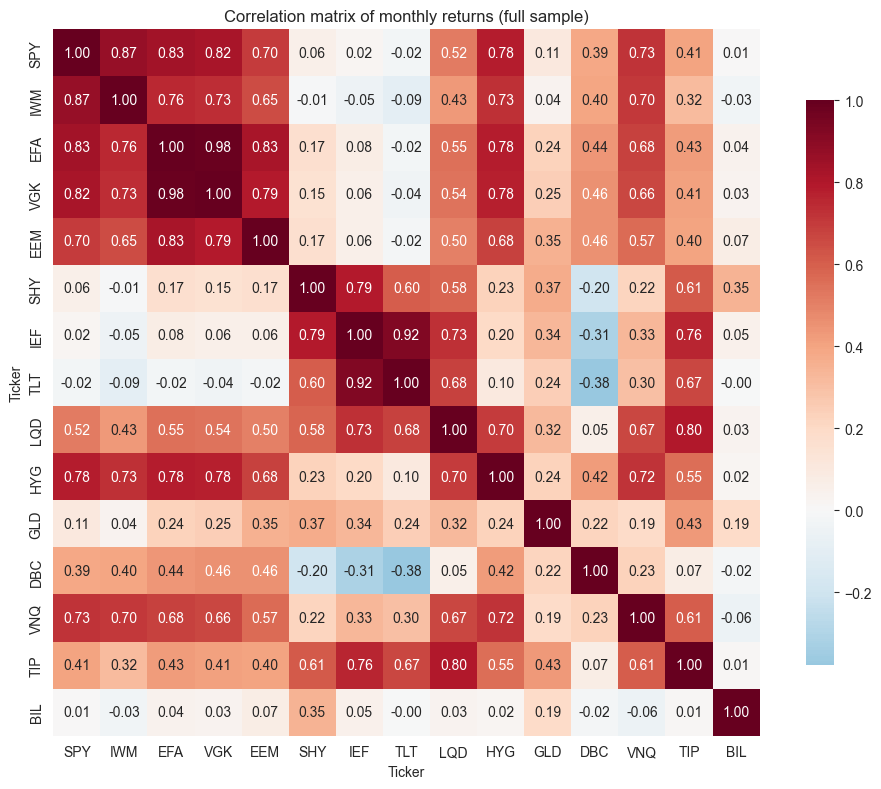

In [48]:
plt.figure(figsize=(10, 8))
sns.heatmap(rets.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix of monthly returns (full sample)')
plt.tight_layout()
plt.show()

## 5. Optimizer building blocks

Standard Markowitz building blocks (as in the reference example), all **long-only** since the
assignment explicitly lists "long-only" among the allowed constraints and it makes the multi-asset
allocation more realistic for this exercise.

In [49]:
def portfolio_variance(w, S):
    return w @ S @ w

def neg_sharpe(w, mu_v, S, rf=0.0):
    ret = w @ mu_v
    vol = np.sqrt(w @ S @ w)
    return -(ret - rf) / vol

def min_variance_weights(mu_v, S):
    n = len(mu_v)
    w0 = np.ones(n) / n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 1)] * n
    res = minimize(portfolio_variance, w0, args=(S,), method='SLSQP',
                    bounds=bounds, constraints=cons, options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else w0

def max_sharpe_weights(mu_v, S, rf=0.0):
    n = len(mu_v)
    w0 = np.ones(n) / n
    cons = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
    bounds = [(0, 1)] * n
    res = minimize(neg_sharpe, w0, args=(mu_v, S, rf), method='SLSQP',
                    bounds=bounds, constraints=cons, options={'ftol': 1e-10, 'maxiter': 500})
    return res.x if res.success else w0

def equal_weight(n):
    return np.ones(n) / n

def sixty_forty_weights(columns):
    """60% equally split across equity tickers, 40% equally split across govt-bond + credit tickers.
    Cash/commodities/gold/REIT/TIPS are excluded, consistent with the classic 60/40 benchmark."""
    eq = [t for t in columns if asset_class[t] == 'Equity']
    bd = [t for t in columns if asset_class[t] in ('Govt Bonds', 'Credit')]
    w = pd.Series(0.0, index=columns)
    w[eq] = 0.60 / len(eq)
    w[bd] = 0.40 / len(bd)
    return w.values

def covariance_estimate(window_rets, shrinkage=True):
    if shrinkage:
        lw = LedoitWolf().fit(window_rets.values)
        S = lw.covariance_
    else:
        S = window_rets.cov().values
    return S * MONTHS_PER_YEAR  # annualize

def michaud_max_sharpe(mu_v, S, n_obs, n_sims=200, rf=0.0, seed=None):
    """Michaud (1989) resampling: simulate n_sims alternative return histories of length n_obs from
    N(mu_v, S/12) [monthly], re-estimate mu_m, Sigma_m on each simulated sample, solve the long-only
    Max-Sharpe problem on (mu_m, Sigma_m), and average the resulting weights across simulations."""
    rng = np.random.default_rng(seed)
    n = len(mu_v)
    S_monthly = S / MONTHS_PER_YEAR
    mu_monthly = mu_v / MONTHS_PER_YEAR
    W = np.zeros((n_sims, n))
    for m in range(n_sims):
        sim = rng.multivariate_normal(mu_monthly, S_monthly, size=n_obs)
        mu_m = sim.mean(axis=0) * MONTHS_PER_YEAR
        S_m = np.cov(sim, rowvar=False) * MONTHS_PER_YEAR
        W[m] = max_sharpe_weights(mu_m, S_m, rf=rf)
    return W.mean(axis=0)

## 6. Rolling, out-of-sample backtest engine

At every rebalancing date $t$ we use **only** the trailing `EST_WINDOW` months of returns
(information available up to $t$, no look-ahead) to estimate $\mu_t,\Sigma_t$ and to compute new
weights for every strategy; those weights are then **held constant** and applied to the realised
returns of the following `REBAL_EVERY` months, out of sample, before the next re-estimation.

In [50]:
strategy_names = ['1/N Equal Weight', '60/40 Naive', 'Markowitz Min-Var',
                   'Markowitz Max-Sharpe', 'Michaud Resampled']

rebal_dates = rets.index[EST_WINDOW::REBAL_EVERY]
print(f'Number of rebalancing dates: {len(rebal_dates)}')
print(f'First rebalancing date: {rebal_dates[0].date()}  (uses the {EST_WINDOW} months before it)')
print(f'Last rebalancing date:  {rebal_dates[-1].date()}')

Number of rebalancing dates: 40
First rebalancing date: 2016-08-31  (uses the 60 months before it)
Last rebalancing date:  2026-05-31


In [51]:
weights_history = {name: [] for name in strategy_names}
weights_dates = []
port_returns = {name: pd.Series(dtype=float) for name in strategy_names}

for i, t in enumerate(rebal_dates):
    loc = rets.index.get_loc(t)
    window = rets.iloc[loc - EST_WINDOW:loc]           # strictly past data only
    mu_t = window.mean().values * MONTHS_PER_YEAR
    S_t = covariance_estimate(window, shrinkage=USE_SHRINKAGE)

    w_eq = equal_weight(n_assets)
    w_6040 = sixty_forty_weights(rets.columns)
    w_minvar = min_variance_weights(mu_t, S_t)
    w_maxsharpe = max_sharpe_weights(mu_t, S_t, rf=RF)
    w_michaud = michaud_max_sharpe(mu_t, S_t, n_obs=EST_WINDOW, n_sims=N_MICHAUD_SIMS, rf=RF, seed=i)

    w_by_strategy = dict(zip(strategy_names, [w_eq, w_6040, w_minvar, w_maxsharpe, w_michaud]))
    weights_dates.append(t)
    for name, w in w_by_strategy.items():
        weights_history[name].append(w)

    # apply these weights out-of-sample until the next rebalancing date (or end of sample)
    next_loc = loc + REBAL_EVERY
    hold_rets = rets.iloc[loc:next_loc]
    for name, w in w_by_strategy.items():
        realized = hold_rets.values @ w
        port_returns[name] = pd.concat([port_returns[name],
                                          pd.Series(realized, index=hold_rets.index)])

for name in strategy_names:
    port_returns[name] = port_returns[name].sort_index()

print('Backtest complete.')
print(f'Out-of-sample period: {port_returns[strategy_names[0]].index.min().date()} -> '
      f'{port_returns[strategy_names[0]].index.max().date()}')

Backtest complete.
Out-of-sample period: 2016-08-31 -> 2026-07-31


## 7. Benchmark / universe index

As required by point 7 of the assignment, we also compute a simple **buy-and-hold benchmark of the
whole universe** (equal-weight at inception, never rebalanced) to represent "the index of the chosen
securities universe", separate from the rebalanced 1/N naive strategy above.

In [52]:
w0 = equal_weight(n_assets)
static_index_rets = rets.iloc[EST_WINDOW:] @ w0
static_index_rets.name = 'Universe buy-and-hold (static 1/N)'

## 8. Performance evaluation

In [53]:
def perf_metrics(r, rf=0.0):
    r = r.dropna()
    n_years = len(r) / MONTHS_PER_YEAR
    growth = (1 + r).cumprod()
    cagr = growth.iloc[-1] ** (1 / n_years) - 1
    ann_vol = r.std() * np.sqrt(MONTHS_PER_YEAR)
    sharpe = (cagr - rf) / ann_vol
    dd = growth / growth.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else np.nan
    return pd.Series({
        'CAGR': cagr, 'Ann. Vol': ann_vol, 'Sharpe': sharpe,
        'Max Drawdown': max_dd, 'Calmar': calmar,
    })

metrics = pd.DataFrame({name: perf_metrics(port_returns[name], RF) for name in strategy_names})
metrics['Universe buy-and-hold'] = perf_metrics(static_index_rets, RF)
metrics = metrics.T
metrics.style.format({'CAGR': '{:.2%}', 'Ann. Vol': '{:.2%}', 'Sharpe': '{:.2f}',
                       'Max Drawdown': '{:.2%}', 'Calmar': '{:.2f}'})

,CAGR,Ann. Vol,Sharpe,Max Drawdown,Calmar
1/N Equal Weight,6.39%,8.49%,0.75,-17.69%,0.36
60/40 Naive,7.32%,10.75%,0.68,-23.45%,0.31
Markowitz Min-Var,2.40%,1.90%,1.26,-5.59%,0.43
Markowitz Max-Sharpe,6.02%,5.63%,1.07,-13.60%,0.44
Michaud Resampled,5.09%,5.19%,0.98,-13.20%,0.39
Universe buy-and-hold,6.39%,8.49%,0.75,-17.69%,0.36


In [54]:
# Turnover: average sum of absolute weight changes at each rebalancing date
def turnover(weights_list):
    W = np.array(weights_list)
    diffs = np.abs(np.diff(W, axis=0)).sum(axis=1)
    return diffs.mean()

turnover_table = pd.Series({name: turnover(weights_history[name]) for name in strategy_names},
                             name='Avg. turnover per rebalance')
turnover_table.to_frame().style.format('{:.1%}')

,Avg. turnover per rebalance
1/N Equal Weight,0.0%
60/40 Naive,0.0%
Markowitz Min-Var,4.9%
Markowitz Max-Sharpe,20.2%
Michaud Resampled,16.0%


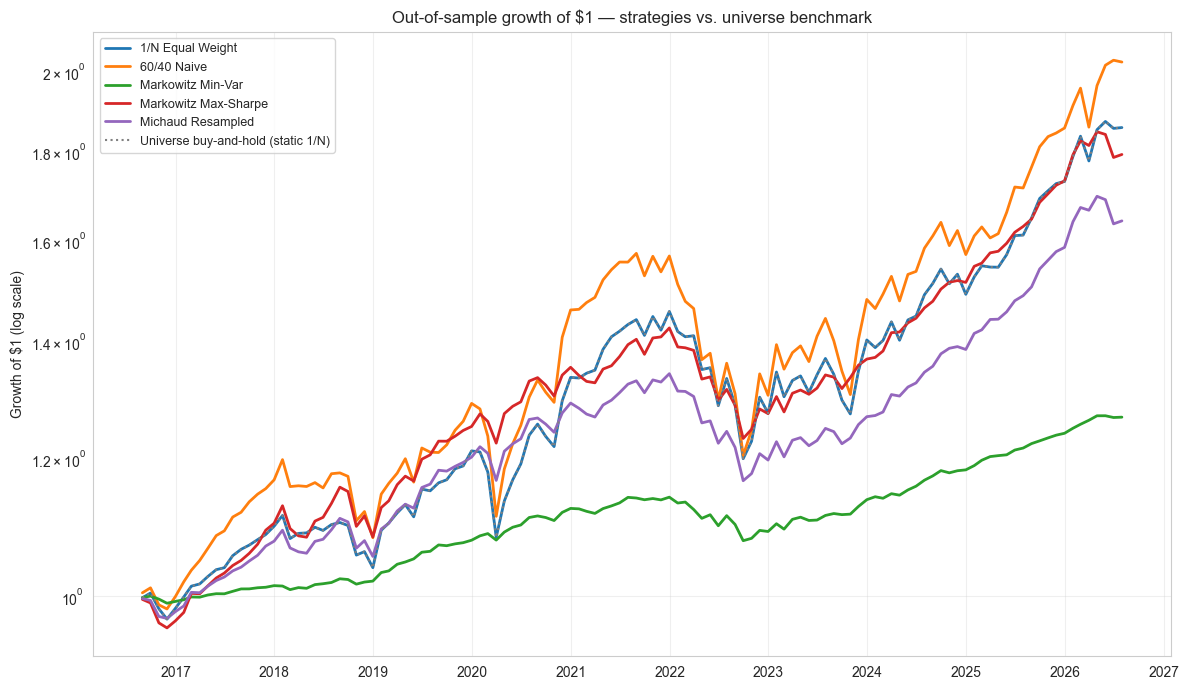

In [55]:
fig, ax = plt.subplots(figsize=(12, 7))
growth_curves = {}
for name in strategy_names:
    growth_curves[name] = (1 + port_returns[name]).cumprod()
    ax.plot(growth_curves[name], label=name, lw=2)
ax.plot((1 + static_index_rets).cumprod(), label=static_index_rets.name, lw=1.5, ls=':', color='gray')

ax.set_yscale('log')
ax.set_ylabel('Growth of $1 (log scale)')
ax.set_title('Out-of-sample growth of $1 — strategies vs. universe benchmark')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

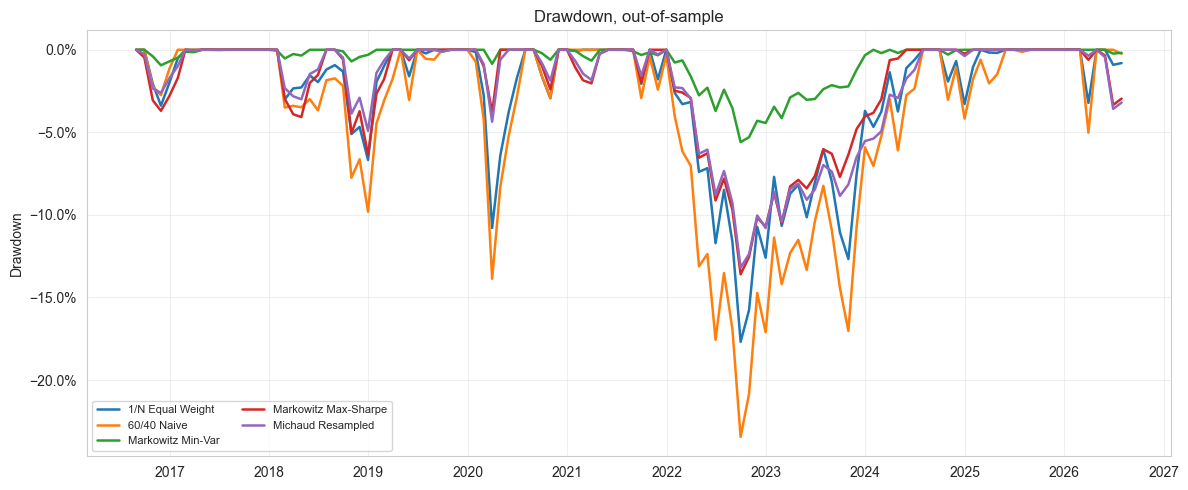

In [56]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in strategy_names:
    dd = growth_curves[name] / growth_curves[name].cummax() - 1
    ax.plot(dd, label=name, lw=1.8)
ax.set_title('Drawdown, out-of-sample')
ax.set_ylabel('Drawdown')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='lower left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

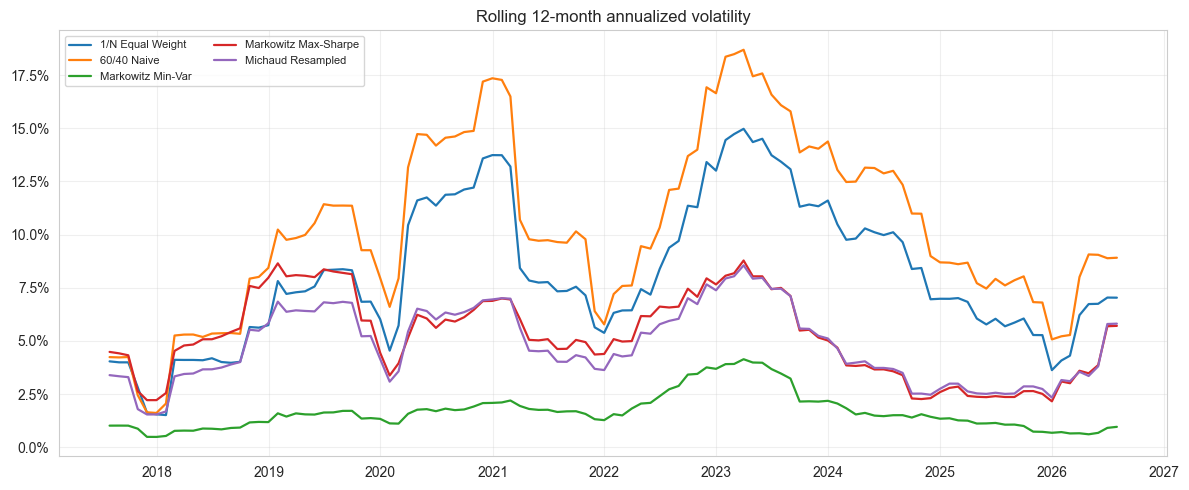

In [57]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in strategy_names:
    roll_vol = port_returns[name].rolling(12).std() * np.sqrt(MONTHS_PER_YEAR)
    ax.plot(roll_vol, label=name, lw=1.6)
ax.set_title('Rolling 12-month annualized volatility')
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.legend(loc='upper left', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 9. Weight stability: Markowitz vs. Michaud

Michaud's original motivation was that classical mean-variance weights are unstable — small changes
in the estimated $\mu,\Sigma$ produce large swings in the optimal weights. Plotting the weight
trajectories over time for the Max-Sharpe Markowitz portfolio and its Michaud-resampled counterpart
is the standard way to show this effect.

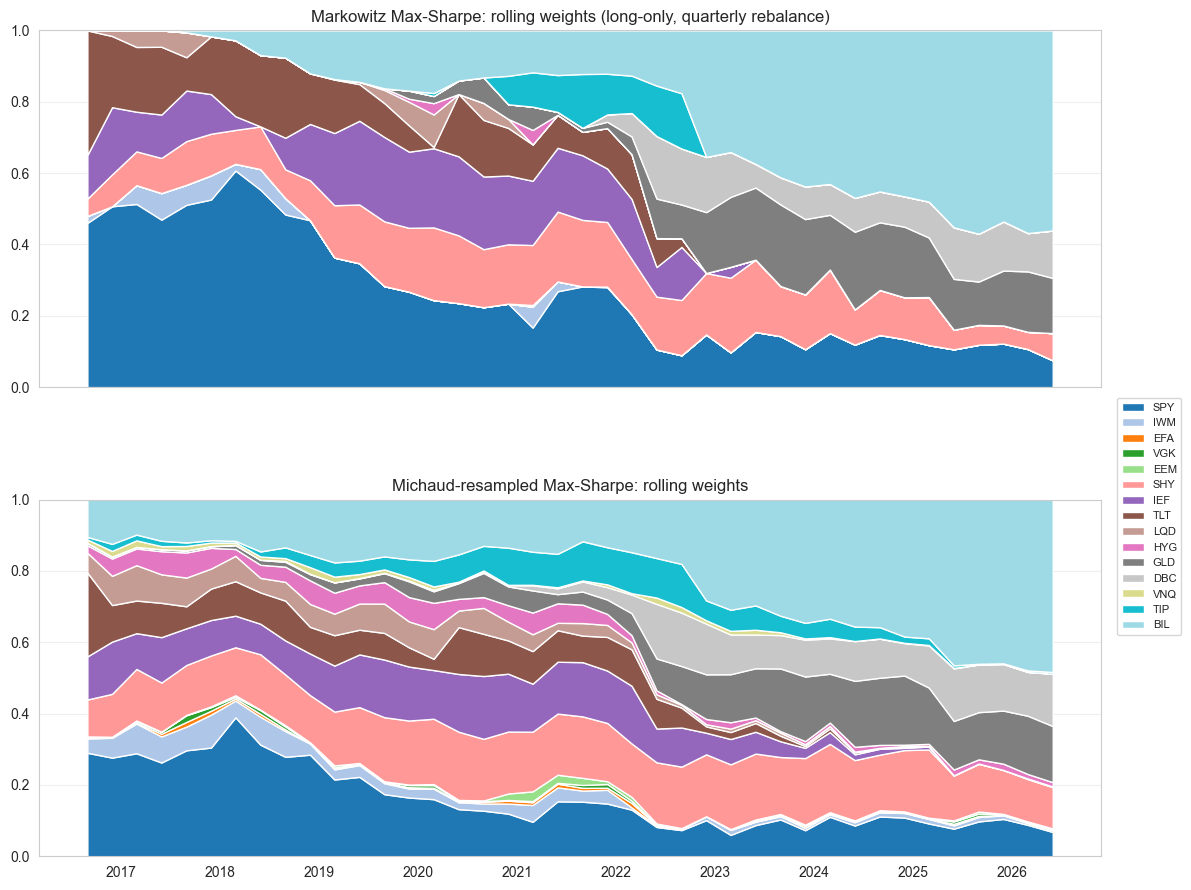

In [58]:
def weights_to_df(name):
    return pd.DataFrame(weights_history[name], index=weights_dates, columns=rets.columns)

W_markowitz = weights_to_df('Markowitz Max-Sharpe')
W_michaud = weights_to_df('Michaud Resampled')
colors = plt.cm.tab20(np.linspace(0, 1, n_assets))

fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
axes[0].stackplot(W_markowitz.index, W_markowitz.T.values, labels=W_markowitz.columns, colors=colors)
axes[0].set_title('Markowitz Max-Sharpe: rolling weights (long-only, quarterly rebalance)')
axes[0].set_ylim(0, 1)

axes[1].stackplot(W_michaud.index, W_michaud.T.values, labels=W_michaud.columns, colors=colors)
axes[1].set_title('Michaud-resampled Max-Sharpe: rolling weights')
axes[1].set_ylim(0, 1)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.01, 1.3), fontsize=8)

plt.tight_layout()
plt.show()

In [59]:
# Quantify the visual impression above: average period-over-period weight change
turnover_table.to_frame('Avg. turnover per rebalance').style.format('{:.1%}')
print('Michaud is expected to show materially lower turnover / smoother weights than plain Markowitz '
      'Max-Sharpe, at the cost of being (by construction) somewhat closer to equal weight.')

Michaud is expected to show materially lower turnover / smoother weights than plain Markowitz Max-Sharpe, at the cost of being (by construction) somewhat closer to equal weight.


## 10. Optional extension — Black-Litterman sketch

The assignment lists Black-Litterman as an optional extension. A full implementation requires
choosing (i) a set of **views** $P, Q$ (which assets/relative bets you have an opinion on and by how
much), (ii) the **confidence matrix** $\Omega$ around those views, and (iii) the scalar $\tau$. Below
is a minimal, documented skeleton — **not run against real views here** — that a group choosing this
extension can fill in and justify in the presentation.

In [60]:
def black_litterman_posterior(mu_market, S, P, Q, omega, tau=0.05):
    """mu_market: CAPM/market-implied prior returns (n,)
    S: covariance matrix (n,n); P: views matrix (k,n); Q: view returns (k,);
    omega: view uncertainty matrix (k,k), typically diag(tau * P @ S @ P.T)."""
    tau_S = tau * S
    inv_tau_S = np.linalg.inv(tau_S)
    inv_omega = np.linalg.inv(omega)
    posterior_cov = np.linalg.inv(inv_tau_S + P.T @ inv_omega @ P)
    posterior_mu = posterior_cov @ (inv_tau_S @ mu_market + P.T @ inv_omega @ Q)
    return posterior_mu, posterior_cov

# Example usage (illustrative only — replace with your own views and run through the same
# rolling backtest loop as Section 6 if you choose to implement this extension):
#
# view 1: "Emerging Markets equity (EEM) will outperform Developed ex-US equity (EFA) by 2%/yr"
# P = np.zeros((1, n_assets)); P[0, list(rets.columns).index('EEM')] = 1; P[0, list(rets.columns).index('EFA')] = -1
# Q = np.array([0.02])
# omega = np.diag(np.diag(P @ (mu_full_cov_or_rolling_S) @ P.T)) * 0.05  # tau-scaled view uncertainty
print('Black-Litterman skeleton defined (not executed — optional extension).')

Black-Litterman skeleton defined (not executed — optional extension).


### 10.1 Black-Litterman Views: "US Exceptionalism & AI Boom"

The standard Markowitz mean-variance optimizer often yields highly concentrated portfolios and is extremely sensitive to historical expected returns. To overcome this limitation, we implement the **Black-Litterman (BL)** model, which allows us to blend market equilibrium returns with subjective, forward-looking macro **views**.

**The Macroeconomic Theme (2026): "US Exceptionalism & AI Boom"**
We base our views on a major current macroeconomic divergence: the persistent economic outperformance of the United States compared to Europe. The US market is heavily supported by massive capital expenditures in Artificial Intelligence, fiscal expansion, and resilient corporate earnings. Conversely, the Eurozone is facing structural stagnation, higher energy vulnerabilities, and a lack of mega-cap tech leadership.

Based on this fundamental divergence, we formulate two relative views:
1. **Equity View (Growth driver):** US Large Cap Equity (`SPY`) will outperform European Equity (`VGK`) by an expected **4.0% annualized**.
2. **Credit View (Risk-on driver):** Thanks to the robust US economy keeping default rates historically low, US High Yield credit (`HYG`) will outperform US Investment Grade (`LQD`) by **1.5% annualized**, compensating investors for the extra credit risk.

In the block below, we define the view matrix $P$, the expected view returns vector $Q$, and compute the posterior expected returns. Notice how the BL model not only adjusts the returns of the targeted assets but also updates the expectations for correlated assets via the covariance matrix (spillover effect).

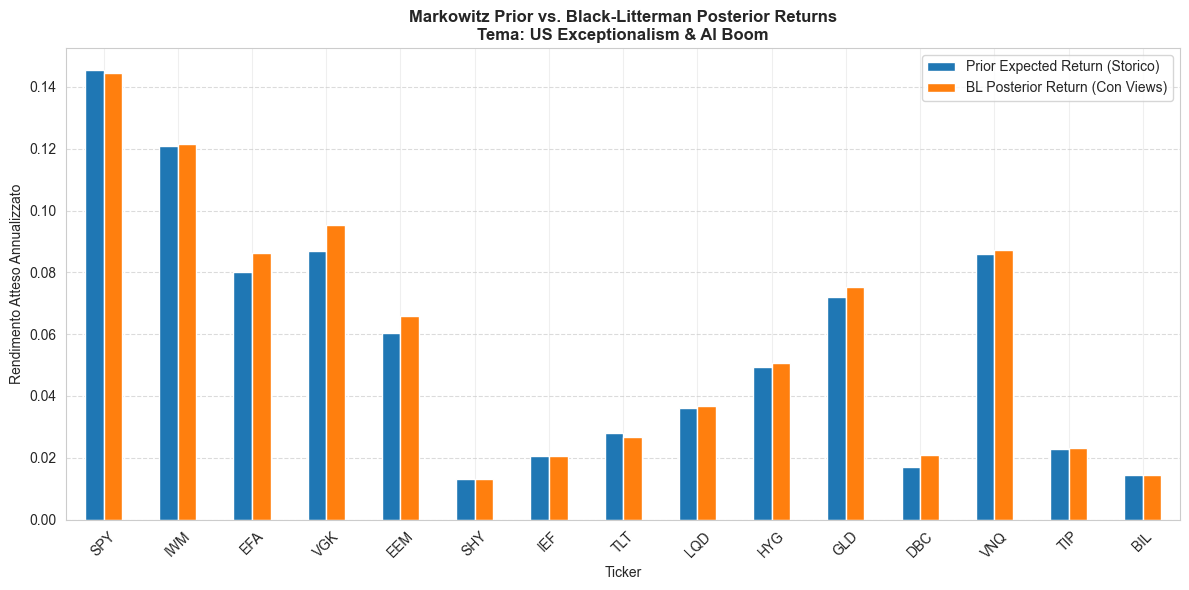

Impatto delle View sui rendimenti attesi:
 - EFA: +0.63%
 - VGK: +0.84%
 - EEM: +0.55%
 - TLT: -0.15%
 - HYG: +0.16%
 - GLD: +0.35%
 - DBC: +0.39%
 - VNQ: +0.12%


In [61]:
# ====================================================================
# 10.1 BLACK-LITTERMAN VIEWS: "US Exceptionalism & AI Boom"
# ====================================================================

# Abbiamo 2 view relative
k_views = 2
P = np.zeros((k_views, n_assets))
Q = np.zeros(k_views)

# Otteniamo gli indici esatti degli ETF nel nostro universo
assets = list(rets.columns)
idx_spy = assets.index('SPY')
idx_vgk = assets.index('VGK')
idx_hyg = assets.index('HYG')
idx_lqd = assets.index('LQD')

# ---------------------------------------------------------
# VIEW 1: L'azionario USA (SPY) sovraperforma l'Europa (VGK) del 4% annuo
# ---------------------------------------------------------
P[0, idx_spy] = 1.0   # Long SPY
P[0, idx_vgk] = -1.0  # Short VGK
Q[0] = 0.04           # +4% di rendimento relativo atteso

# ---------------------------------------------------------
# VIEW 2: Il credito High Yield (HYG) sovraperforma l'Investment Grade (LQD) dell'1.5%
# ---------------------------------------------------------
P[1, idx_hyg] = 1.0   # Long HYG
P[1, idx_lqd] = -1.0  # Short LQD
Q[1] = 0.015          # +1.5% di rendimento relativo atteso

# ---------------------------------------------------------
# CALCOLO DELLA MATRICE DI COVARIANZA, INCERTEZZA (Omega) E POSTERIOR
# ---------------------------------------------------------
tau = 0.05

# RISOLUZIONE ERRORE: Calcoliamo la matrice di covarianza completa (15x15)
cov_full = covariance_estimate(rets, shrinkage=USE_SHRINKAGE)

# Ora le dimensioni sono corrette: (2x15) @ (15x15) @ (15x2) = matrice 2x2
omega = np.diag(np.diag(P @ cov_full @ P.T)) * tau

# Eseguiamo il modello Black-Litterman 
# Passiamo mu_full.values per avere un array numpy puro
post_mu, post_cov = black_litterman_posterior(mu_full.values, cov_full, P, Q, omega, tau=tau)

# ---------------------------------------------------------
# VISUALIZZAZIONE DEI RISULTATI
# ---------------------------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

bl_comparison = pd.DataFrame({
    'Prior Expected Return (Storico)': mu_full.values,
    'BL Posterior Return (Con Views)': post_mu
}, index=rets.columns)

fig, ax = plt.subplots(figsize=(12, 6))
bl_comparison.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e'])
ax.set_title("Markowitz Prior vs. Black-Litterman Posterior Returns\nTema: US Exceptionalism & AI Boom", fontweight='bold')
ax.set_ylabel("Rendimento Atteso Annualizzato")
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Stampiamo le differenze percentuali per evidenziare il lavoro dell'algoritmo
print("Impatto delle View sui rendimenti attesi:")
diff = pd.Series(post_mu - mu_full.values, index=rets.columns) * 100
for asset, val in diff.items():
    if abs(val) > 0.1: # Filtriamo solo gli asset significativamente impattati
        print(f" - {asset}: {val:+.2f}%")

### 10.2 Out-of-Sample Rolling Backtest: Markowitz vs. Black-Litterman

While observing the static shift in expected returns is insightful, the true power of an asset allocation strategy must be tested out-of-sample. In this section, we integrate the Black-Litterman model into our rolling backtest engine defined in Section 6.

**Dynamic Uncertainty Adjustment**
In a real-world scenario, market risk is not constant. By running BL inside a rolling loop, we estimate the historical equilibrium (Prior $\mu_t$) and the covariance matrix ($\Sigma_t$) using only the strictly trailing 60-month window. 
Crucially, the uncertainty matrix of our views ($\Omega_t$) is recalculated at each rebalancing date as a function of the rolling $\Sigma_t$. This means that during periods of high market volatility, the model automatically reduces its confidence in our subjective views and shrinks the portfolio closer to the historical equilibrium, acting as a built-in risk management mechanism.

We will run the Max-Sharpe optimizer on the newly generated BL posterior returns and compare its out-of-sample trajectory against the purely historical Markowitz Max-Sharpe portfolio.

Avvio del backtest rolling per Black-Litterman...
Backtest Black-Litterman completato!



,CAGR,Ann. Vol,Sharpe,Max Drawdown,Calmar
Markowitz Max-Sharpe,6.02%,5.63%,1.07,-13.60%,0.44
Black-Litterman (Views),5.94%,5.64%,1.05,-13.40%,0.44


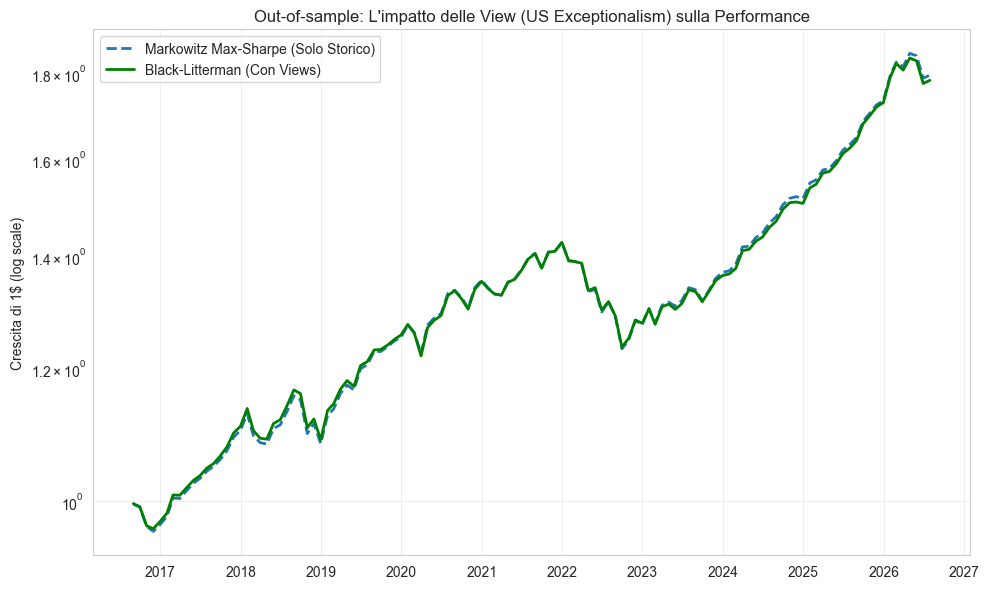

In [62]:
# ====================================================================
# 10.2 BACKTEST ROLLING: MARKOWITZ vs BLACK-LITTERMAN
# ====================================================================
# Definiamo le view (come fatto in precedenza)
k_views = 2
P = np.zeros((k_views, n_assets))
Q = np.zeros(k_views)
assets = list(rets.columns)

P[0, assets.index('SPY')] = 1.0
P[0, assets.index('VGK')] = -1.0
Q[0] = 0.04  # +4% US vs EU

P[1, assets.index('HYG')] = 1.0
P[1, assets.index('LQD')] = -1.0
Q[1] = 0.015 # +1.5% HY vs IG

tau = 0.05

# Strutture dati per il nuovo backtest
pesi_bl_history = []
ritorni_bl = pd.Series(dtype=float)

print("Avvio del backtest rolling per Black-Litterman...")

# Riutilizziamo le date di ribilanciamento già calcolate nella Sezione 6
for i, t in enumerate(rebal_dates):
    loc = rets.index.get_loc(t)
    window = rets.iloc[loc - EST_WINDOW:loc] # Finestra rolling di 60 mesi
    
    # 1. Stime storiche (Prior)
    mu_t = window.mean().values * MONTHS_PER_YEAR
    S_t = covariance_estimate(window, shrinkage=USE_SHRINKAGE)
    
    # 2. Incertezza delle view dinamica
    # Omega_t viene ricalcolata usando la S_t della finestra corrente!
    omega_t = np.diag(np.diag(P @ S_t @ P.T)) * tau
    
    # 3. Calcolo dei Posterior Expected Returns e Covariance
    post_mu, post_cov = black_litterman_posterior(mu_t, S_t, P, Q, omega_t, tau)
    
    # 4. Ottimizzazione Max-Sharpe usando i nuovi parametri di Black-Litterman
    # Utilizziamo la funzione max_sharpe_weights definita nella Sezione 5
    w_bl = max_sharpe_weights(post_mu, post_cov, rf=RF)
    pesi_bl_history.append(w_bl)
    
    # 5. Calcolo rendimenti out-of-sample
    next_loc = loc + REBAL_EVERY
    hold_rets = rets.iloc[loc:next_loc]
    realized = hold_rets.values @ w_bl
    ritorni_bl = pd.concat([ritorni_bl, pd.Series(realized, index=hold_rets.index)])

ritorni_bl = ritorni_bl.sort_index()
ritorni_bl.name = 'Black-Litterman (US Exceptionalism)'
print("Backtest Black-Litterman completato!\n")

# ====================================================================
# 10.3 CONFRONTO PERFORMANCE: MARKOWITZ vs BLACK-LITTERMAN
# ====================================================================
# Aggiungiamo BL alle metriche per confrontarlo con il Max-Sharpe storico

bl_metrics = perf_metrics(ritorni_bl, RF)
ms_metrics = perf_metrics(port_returns['Markowitz Max-Sharpe'], RF)

confronto_df = pd.DataFrame({
    'Markowitz Max-Sharpe': ms_metrics,
    'Black-Litterman (Views)': bl_metrics
}).T

display(confronto_df.style.format({'CAGR': '{:.2%}', 'Ann. Vol': '{:.2%}', 'Sharpe': '{:.2f}',
                       'Max Drawdown': '{:.2%}', 'Calmar': '{:.2f}'}))

# Grafico della crescita comparata
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot((1 + port_returns['Markowitz Max-Sharpe']).cumprod(), label='Markowitz Max-Sharpe (Solo Storico)', lw=2, linestyle='--')
ax.plot((1 + ritorni_bl).cumprod(), label='Black-Litterman (Con Views)', lw=2, color='green')
ax.set_yscale('log')
ax.set_ylabel('Crescita di 1$ (log scale)')
ax.set_title('Out-of-sample: L\'impatto delle View (US Exceptionalism) sulla Performance')
ax.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Sensitivity to subjective parameters (optional but recommended)

The assignment explicitly asks you to justify the estimation window, rebalancing frequency,
constraints, etc. A light sensitivity table — re-running the Max-Sharpe strategy only, for speed — is
a good way to show this in the presentation.

In [63]:
def backtest_maxsharpe_only(est_window, rebal_every, shrinkage=True, rf=0.0):
    rb_dates = rets.index[est_window::rebal_every]
    out = pd.Series(dtype=float)
    for t in rb_dates:
        loc = rets.index.get_loc(t)
        window = rets.iloc[loc - est_window:loc]
        mu_t = window.mean().values * MONTHS_PER_YEAR
        S_t = covariance_estimate(window, shrinkage=shrinkage)
        w = max_sharpe_weights(mu_t, S_t, rf=rf)
        next_loc = loc + rebal_every
        hold = rets.iloc[loc:next_loc]
        out = pd.concat([out, pd.Series(hold.values @ w, index=hold.index)])
    return out.sort_index()

sensitivity_rows = []
for est_w in [36, 60, 84]:
    for rebal in [1, 3, 6]:
        r = backtest_maxsharpe_only(est_w, rebal, shrinkage=USE_SHRINKAGE, rf=RF)
        m = perf_metrics(r, RF)
        sensitivity_rows.append({'Est. window (m)': est_w, 'Rebal. freq (m)': rebal,
                                   'CAGR': m['CAGR'], 'Ann. Vol': m['Ann. Vol'], 'Sharpe': m['Sharpe']})

sensitivity = pd.DataFrame(sensitivity_rows)
sensitivity.style.format({'CAGR': '{:.2%}', 'Ann. Vol': '{:.2%}', 'Sharpe': '{:.2f}'})

,Est. window (m),Rebal. freq (m),CAGR,Ann. Vol,Sharpe
0,36,1,4.46%,6.42%,0.69
1,36,3,4.57%,6.68%,0.68
2,36,6,5.26%,6.79%,0.77
3,60,1,5.79%,5.34%,1.08
4,60,3,6.02%,5.63%,1.07
5,60,6,5.98%,5.77%,1.04
6,84,1,5.96%,5.97%,1.00
7,84,3,6.03%,6.23%,0.97
8,84,6,6.52%,6.33%,1.03


## 12. Discussion notes (fill in for the presentation)

- **Universe, sample period and data provider.** State explicitly why these 15 ETFs, why 15 years
  (data availability vs. capturing at least one full equity bear market, e.g. 2020 and/or 2022), and
  why Yahoo Finance (free, sufficiently long history, adjusted total-return prices).
- **Did dynamic allocation add value vs. the benchmark?** Compare the Sharpe ratio and drawdown of
  Markowitz/Michaud against the naive 1/N, naive 60/40 and the static universe buy-and-hold from
  Sections 6-8: rank them and explain *why*, referencing the estimation-risk trade-off central to the
  Markowitz vs. Michaud comparison (Michaud, 1989).
- **Weight stability.** Use the Section 9 plots and the turnover table to discuss whether Michaud
  resampling delivered materially smoother, less estimation-error-driven allocations, and at what cost
  in realised performance.
- **Sensitivity.** Summarize how sensitive your conclusions are to the estimation window and
  rebalancing frequency (Section 11) — a strategy that only "works" for one specific parameter choice
  is a red flag the professor will likely probe in the oral exam.
- **Limitations.** No transaction costs are modelled here (see the turnover table as a proxy for
  implied trading activity); returns are ETF-level, not index-level, so there is some tracking error
  vs. the underlying benchmarks; and the Black-Litterman extension (Section 10) was only sketched, not
  fully calibrated with real views.